Посещаемость ресторанов

In [16]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

from src.data import prepare

df = prepare(ROOT / "data" / "raw" / "guests.csv")
df.head()

,date,restaurant_id,guests,revenue,is_missing,is_closed,guests_raw,is_outlier
0,2024-10-01,1,141.0,211521.14,0,0,141.0,0
1,2024-10-02,1,153.0,232758.36,0,0,153.0,0
2,2024-10-03,1,127.0,183959.97,0,0,127.0,0
3,2024-10-04,1,202.0,301649.81,0,0,202.0,0
4,2024-10-05,1,187.0,258959.35,0,0,187.0,0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1309 non-null   datetime64[ns]
 1   restaurant_id  1309 non-null   int64         
 2   guests         1268 non-null   float64       
 3   revenue        1268 non-null   float64       
 4   is_missing     1309 non-null   int64         
 5   is_closed      1309 non-null   int64         
 6   guests_raw     1274 non-null   float64       
 7   is_outlier     1309 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(4)
memory usage: 81.9 KB


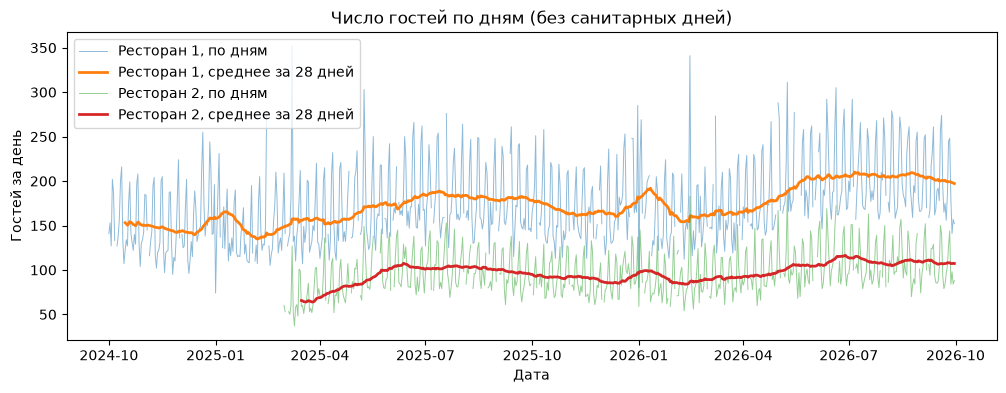

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

for rid, g in df.groupby("restaurant_id"):
    open_guests = g["guests"].where(g["is_closed"] == 0)
    ax.plot(g["date"], open_guests, lw=0.7, alpha=0.5,
            label=f"Ресторан {rid}, по дням")
    ax.plot(g["date"], open_guests.rolling(28, min_periods=14).mean(), lw=2,
            label=f"Ресторан {rid}, среднее за 28 дней")

ax.set_title("Число гостей по дням (без санитарных дней)")
ax.set_xlabel("Дата")
ax.set_ylabel("Гостей за день")
ax.legend()
plt.show()

Оба ресторана медленно растут, и каждый год повторяется летний пик и декабрьский всплеск. Ресторан 2 открылся в марте 2025 и первые 2–3 месяца набирал посещаемость. Для модели нужны признак текущего уровня (среднее за последние 4 недели), чтобы учитывать рост и раскрутку, и месяц, чтобы учитывать сезон.

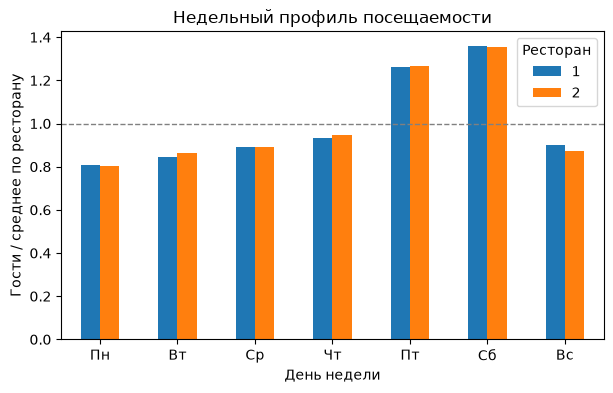

restaurant_id,1,2
dow,,
0,0.81,0.80
1,0.85,0.86
2,0.89,0.89
3,0.93,0.94
4,1.26,1.27
5,1.36,1.35
6,0.90,0.88


In [19]:
open_days = df[df["is_closed"] == 0].copy()
open_days["dow"] = open_days["date"].dt.dayofweek

profile = open_days.groupby(["restaurant_id", "dow"])["guests"].mean().unstack(0)
profile = profile / profile.mean()

fig, ax = plt.subplots(figsize=(7, 4))
profile.plot(kind="bar", ax=ax)
ax.set_xticklabels(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"], rotation=0)
ax.axhline(1, color="gray", linestyle="--", linewidth=1)
ax.set_title("Недельный профиль посещаемости")
ax.set_xlabel("День недели")
ax.set_ylabel("Гости / среднее по ресторану")
ax.legend(title="Ресторан")
plt.show()

profile.round(2)

Сильнее всего от среднего отличаются пятница (+26%) и суббота (+36%), слабее всего — понедельник (−20%). По загрузке пятница ближе к субботе, чем к будням, поэтому в признаке is_weekend она считается выходным. Форма недели у двух ресторанов совпадает (расхождение ≤ 0.02), значит, одну модель можно учить на обоих ресторанах сразу, а разницу в масштабе учтёт признак уровня. Для модели нужен признак дня недели.

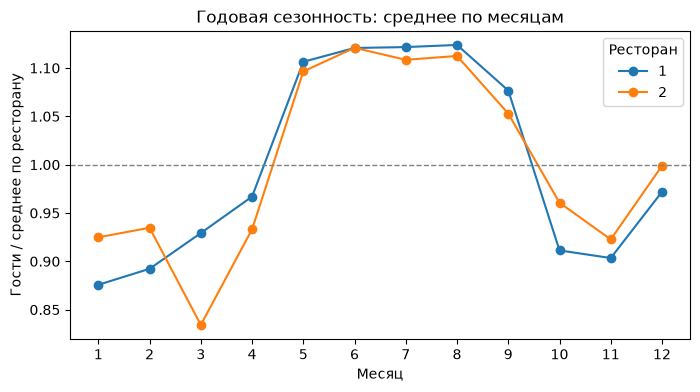

restaurant_id,1,2
month,,
1,0.88,0.92
2,0.89,0.93
3,0.93,0.83
4,0.97,0.93
5,1.11,1.10
6,1.12,1.12
7,1.12,1.11
8,1.12,1.11
9,1.08,1.05


In [20]:
open_days["month"] = open_days["date"].dt.month

month_profile = open_days.groupby(["restaurant_id", "month"])["guests"].mean().unstack(0)
month_profile = month_profile / month_profile.mean()

fig, ax = plt.subplots(figsize=(8, 4))
month_profile.plot(marker="o", ax=ax)
ax.axhline(1, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(1, 13))
ax.set_title("Годовая сезонность: среднее по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Гости / среднее по ресторану")
ax.legend(title="Ресторан")
plt.show()

month_profile.round(2)

Посещаемость имеет годовой цикл: с мая по сентябрь гостей на 10–12% больше среднего (сезон веранд), в январе–феврале и октябре–ноябре примерно на 10% меньше. У ресторана 2 март заметно ниже (0.83), потому что его единственный полный «старый» март пришёлся на первые недели после открытия (раскрутка), средние по месяцам для него смещены. Для модели нужен признак месяца, а признак текущего уровня (среднее за 4 недели) дополнительно защитит от смещения из-за раскрутки.

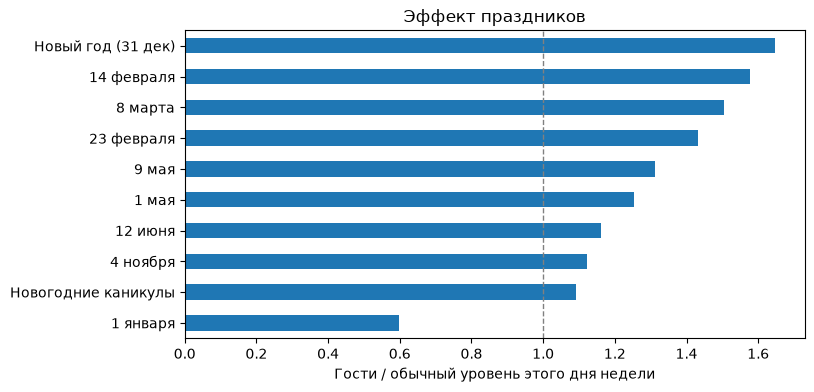

holiday
1 января               0.60
Новогодние каникулы    1.09
4 ноября               1.12
12 июня                1.16
1 мая                  1.25
9 мая                  1.31
23 февраля             1.43
8 марта                1.51
14 февраля             1.58
Новый год (31 дек)     1.65
Name: ratio, dtype: float64

In [21]:
from src.holidays import holiday_name

open_days["holiday"] = holiday_name(open_days["date"])

# «обычный уровень»: медиана того же дня недели в соседних неделях
open_days["typical"] = open_days.groupby(["restaurant_id", "dow"])["guests"].transform(
    lambda s: s.rolling(7, center=True, min_periods=4).median())
open_days["ratio"] = open_days["guests"] / open_days["typical"]

holiday_effect = (open_days.dropna(subset=["holiday"])
                  .groupby("holiday")["ratio"].mean().sort_values())

fig, ax = plt.subplots(figsize=(8, 4))
holiday_effect.plot(kind="barh", ax=ax)
ax.axvline(1, color="gray", linestyle="--", linewidth=1)
ax.set_title("Эффект праздников")
ax.set_xlabel("Гости / обычный уровень этого дня недели")
ax.set_ylabel("")
plt.show()

holiday_effect.round(2)

Праздники заметно меняют посещаемость относительно обычного уровня того же дня недели: сильнее всего 31 декабря (×1.65), 14 февраля (×1.58) и 8 марта (×1.51), а 1 января, наоборот, даёт спад (×0.60). Самый сильный праздничный эффект меньше порога выбросов (2.5), поэтому ни один праздник не был ошибочно удалён при очистке: Новый год это событие, а не выброс. Для модели нужен признак праздника; 1 января стоит выделить отдельно, иначе эффекты роста и спада смешаются в одном флаге.

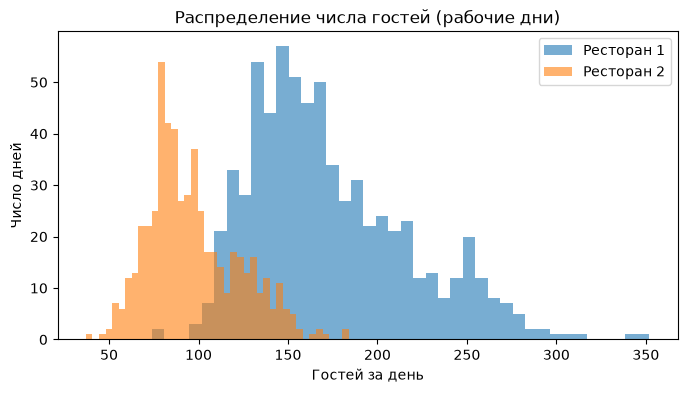

,mean,median,std,skew
restaurant_id,,,,
1,173.09,164.0,44.36,0.81
2,96.58,92.0,25.06,0.67


In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
for rid, g in open_days.groupby("restaurant_id"):
    ax.hist(g["guests"].dropna(), bins=40, alpha=0.6, label=f"Ресторан {rid}")
ax.set_title("Распределение числа гостей (рабочие дни)")
ax.set_xlabel("Гостей за день")
ax.set_ylabel("Число дней")
ax.legend()
plt.show()

open_days.groupby("restaurant_id")["guests"].agg(["mean", "median", "std", "skew"]).round(2)

Распределение гостей несимметрично — длинный хвост вправо, среднее больше медианы (173 против 164 у ресторана 1). Хвост возникает в дни, когда совпадают несколько множителей роста (пятница, лето, праздник), следствие мультипликативной структуры ряда. Рестораны отличаются по масштабу почти вдвое: ошибка в 15 гостей это 9% для ресторана 1 и 16% для ресторана 2. Поэтому, кроме MAE, считаем MAPE, чтобы сравнивать точность на разных ресторанах; логарифм целевой может помочь линейной модели, превращая произведение множителей в сумму.

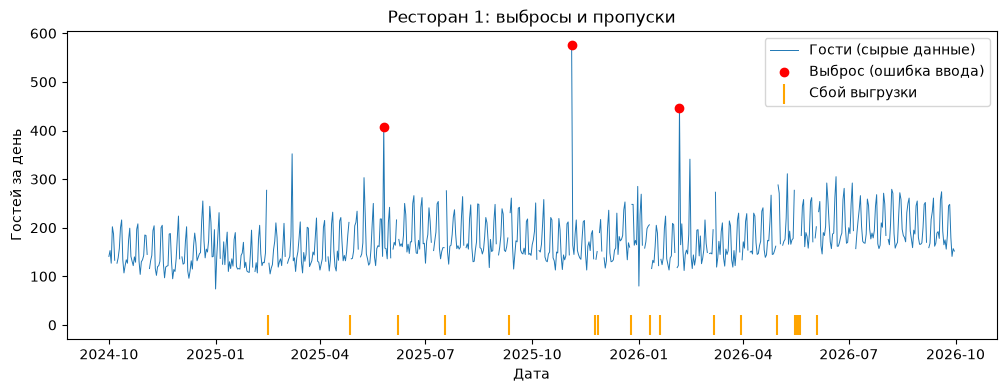

In [23]:
r1 = df[df["restaurant_id"] == 1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(r1["date"], r1["guests_raw"].where(r1["is_closed"] == 0),
        lw=0.7, label="Гости (сырые данные)")

outliers = r1[r1["is_outlier"] == 1]
ax.scatter(outliers["date"], outliers["guests_raw"], color="red", zorder=3,
           label="Выброс (ошибка ввода)")

missing = r1[r1["is_missing"] == 1]
ax.scatter(missing["date"], [0] * len(missing), marker="|", s=200, color="orange",
           label="Сбой выгрузки")

ax.set_title("Ресторан 1: выбросы и пропуски")
ax.set_xlabel("Дата")
ax.set_ylabel("Гостей за день")
ax.legend()
plt.show()

Выбросы, найденные при очистке, резко выделяются над обычным уровнем (в примерно 3 раза выше типичного дня), тогда как праздничные всплески не превышают ×1.7 по масштабу это разные явления. Сбои выгрузки в основном разбросаны случайно, но есть и блок из 5 дней подряд. Пропущенные дни восстановлены в календаре как NaN, а не удалены, поэтому лаги считаются по настоящим датам: «7 строк назад» всегда означает «неделю назад».

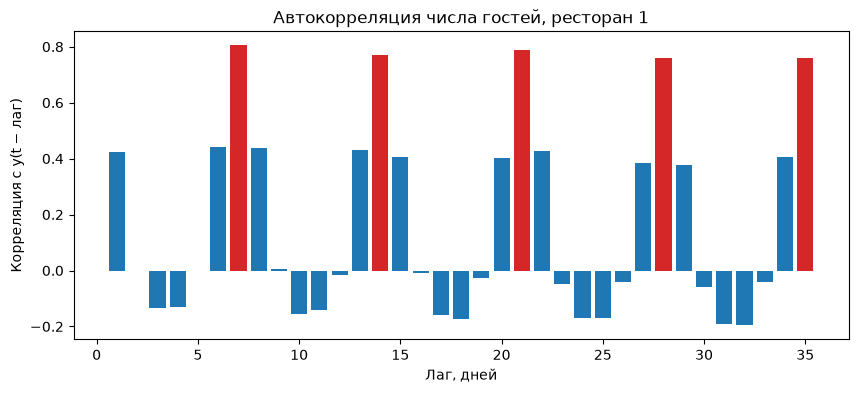

1     0.42
2    -0.00
3    -0.13
4    -0.13
5    -0.00
6     0.44
7     0.80
8     0.44
9     0.01
10   -0.15
11   -0.14
12   -0.02
13    0.43
14    0.77
15    0.41
16   -0.01
17   -0.16
18   -0.17
19   -0.03
20    0.40
21    0.79
22    0.43
23   -0.05
24   -0.17
25   -0.17
26   -0.04
27    0.38
28    0.76
29    0.38
30   -0.06
31   -0.19
32   -0.20
33   -0.04
34    0.41
35    0.76
dtype: float64

In [24]:
guests_open = r1["guests"].where(r1["is_closed"] == 0).reset_index(drop=True)

lags = range(1, 36)
acf = pd.Series([guests_open.autocorr(lag=k) for k in lags], index=lags)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tab:red" if k % 7 == 0 else "tab:blue" for k in lags]
ax.bar(acf.index, acf.values, color=colors)
ax.set_title("Автокорреляция числа гостей, ресторан 1")
ax.set_xlabel("Лаг, дней")
ax.set_ylabel("Корреляция с y(t − лаг)")
plt.show()

acf.round(2)

Автокорреляция имеет пики на лагах 7, 14, 21, 28, 35 (≈ 0.8) и близка к нулю между ними: сегодняшний день сильнее всего похож на тот же день недели в прошлые недели. «Вчера» (lag 1, ≈ 0.4) информативнее случайного дня, но слабее «неделю назад», потому что вчера другой день недели. При прогнозе на 7 дней вперёд разрешены только лаги от 7 и больше (более близкие дни ещё не наступили), и это удачно совпадает с данными: самые информативные лаги — именно кратные неделе. Для модели берём lag_7, lag_14, lag_21, lag_28.